# CPU inference in a character-level MLP

An educational performance study of batching and inference-time BatchNorm folding.

**Recorded finding:** at batch size 32, folding reduced a fixed 128-context workload from 1.317 to 0.703 ms and from 1.311 to 0.702 ms in two rounds (about 1.87x). Full validation: 22,767 contexts, zero changed argmax predictions, maximum absolute logit difference 2.86e-6.

The executable cells and their saved outputs below are preserved from the supplied notebook. Explanatory Markdown was added during packaging; the training and benchmarks were not rerun. This is a documented learning experiment, not a novel algorithm or a peer-reviewed publication.

See README.md and REPORT.md for reproduction requirements, attribution, and limitations. The original run used a double shuffle; retain it when attempting to reproduce these results. Rerun from a fresh kernel and execute in order. Training/initialization must precede folding. A notebook file does not contain the live trained tensors.


## Setup
Requires PyTorch, matplotlib, and the original names.txt file. Exact historical package versions were not captured.

In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random

## Dataset
The supplied code shuffles after loading and again before splitting. A full ordered run is deterministic for the same input file and software behaviour; rerunning only the split cell mutates the ordering again. Preserved for result provenance.

In [3]:
words = open('names.txt' , 'r').read().splitlines()
random.Random(42).shuffle(words)

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = { s:i+1 for i , s in enumerate (chars)}
stoi ['.'] = 0
itos = {i:s for s , i in stoi.items()}
print (itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3
def build_dataset(words):
    X = []
    Y = []
    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)

            context = context[1 :] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print (X.shape , Y.shape)
    return X , Y

random.seed(42)
random.shuffle(words)
n1 = int (0.8 * len(words))
n2 = int (0.9 * len(words))

Xtr , Ytr = build_dataset (words[:n1])
Xdev , Ydev = build_dataset(words[n1 : n2])
Xte , Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [6]:
g = torch.Generator().manual_seed(2147483647)

## Model
Context length 3; embedding width 10; five hidden widths of 100; 27 output logits; 47,551 trainable parameters. Custom BatchNorm uses sample variance, momentum 0.5, epsilon 1e-5. This is not claimed to match all torch.nn.BatchNorm1d training conventions.

In [7]:
class Linear:

    def __init__(self , fan_in , fan_out , bias = True):
        self.weight = torch.randn((fan_in , fan_out) , generator = g) / fan_in**0.5
        self.bias   = torch.zeros(fan_out) if bias else None
    def __call__(self , x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])#[self.bias] if self.bias else []

class BatchNorm1d:

  def __init__(self , dim , momentum = 0.5 , epsilon =1e-5):
    self.momentum = momentum
    self.epsilon = epsilon
    self.training = True
    #BatchNorm Scaling parameters Trained with the parameters
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    #Buffers (Trained with the running momentum update --Janky)
    self.running_mean = torch.zeros(dim) # Gaussian Zero mean , 1 var
    self.running_var = torch.ones(dim)

  def __call__ (self , x):
    if self.training:
      xmean = x.mean( 0 , keepdim=True)
      xvar = x.var( 0 , keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var

    xhat = (x - xmean) / torch.sqrt(xvar + self.epsilon)

    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters (self):
    return [self.gamma , self.beta]


class Tanh:

    def __call__ (self , x):
        self.out = torch.tanh (x)
        return self.out
    def parameters (self):
        return []

n_embd = 10
n_hidden = 100
vocab_size = 27
block_size = 3
g = torch.Generator().manual_seed(2147483647)

C = torch.randn( (vocab_size , n_embd) , generator = g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden , n_hidden) , BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden , n_hidden) , BatchNorm1d(n_hidden) , Tanh(),
    Linear(n_hidden , n_hidden) , BatchNorm1d(n_hidden) , Tanh(),
    Linear(n_hidden , n_hidden) , BatchNorm1d(n_hidden) , Tanh(),
    Linear(n_hidden , vocab_size) , BatchNorm1d(vocab_size)
]

with torch.no_grad():
    layers[-1].gamma *= 0.1
    for layer in layers[ :-1]:
        if isinstance(layer , Linear):
            layer.weight *= 5/3

parameters = [C] + [ p for layer in layers for p in layer.parameters()]
print (sum ( p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

47551


In [8]:
def forward(x):
  emb = C[x]
  x = emb.view(emb.shape[0] , -1)
  for layer in layers:
      x = layer(x)
  return x

## Training
Recorded configuration: 10,000 SGD steps, batch 32, learning rate 0.1. Diagnostic work is included here but excluded from inference timing. The existing .data usage is retained as historical code; a future training revision can use p.add_(p.grad, alpha=-lr) inside no_grad instead.

In [9]:
max_steps = 10000
batch_size = 32
ud = []
lossi = []

# Putting model in training mode
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = True

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size, ) , generator = g)
    Xb , Yb = Xtr [ix] , Ytr [ix]
    x = forward(Xb)

    loss = F.cross_entropy (x , Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1
    with torch.no_grad():
      for p in parameters:
          p.data += -lr * p.grad

    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])


      0/  10000: 3.3313


## Diagnostics
Run these cells before inference overwrites layer.out. Saved plots reflect the training run, not the folded model.

layer 2 (      Tanh): mean +0.000000, std 3.766654e-03
layer 5 (      Tanh): mean -0.000000, std 3.346551e-03
layer 8 (      Tanh): mean -0.000000, std 3.311855e-03
layer 11 (      Tanh): mean -0.000000, std 3.226783e-03
layer 14 (      Tanh): mean +0.000000, std 2.957410e-03


Text(0.5, 1.0, 'gradient distribution')

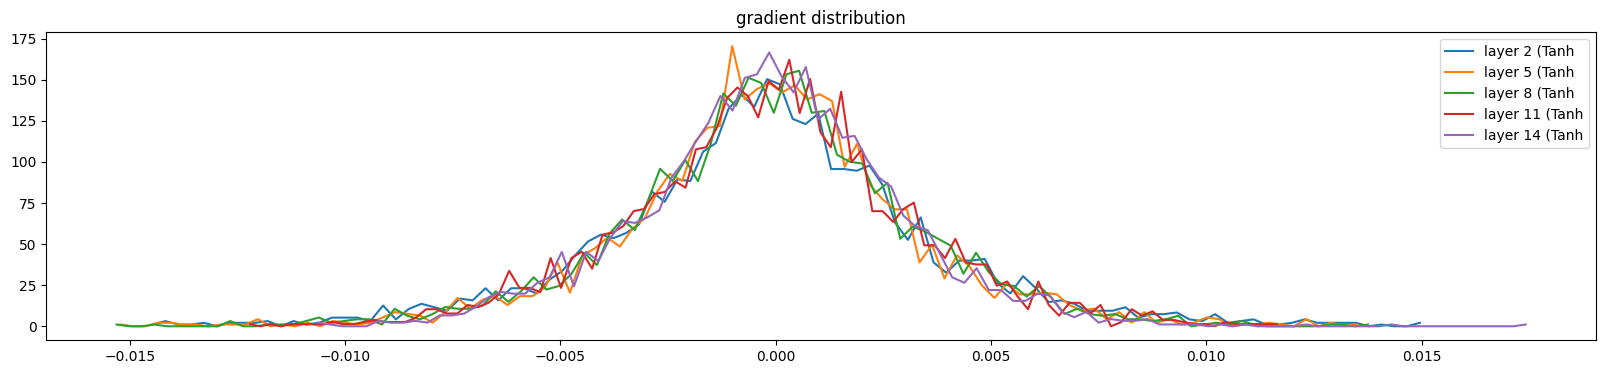

In [10]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')



/tmp/ipykernel_433/3536293011.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))


weight   (27, 10) | mean -0.000000 | std 1.068115e-02 | grad:data ratio 1.061878e-02
weight  (30, 100) | mean -0.000082 | std 8.626959e-03 | grad:data ratio 2.678408e-02
weight (100, 100) | mean -0.000116 | std 6.581208e-03 | grad:data ratio 3.695688e-02
weight (100, 100) | mean +0.000034 | std 6.159778e-03 | grad:data ratio 3.469939e-02
weight (100, 100) | mean +0.000059 | std 5.997962e-03 | grad:data ratio 3.412175e-02
weight (100, 100) | mean +0.000042 | std 5.372131e-03 | grad:data ratio 3.072614e-02
weight  (100, 27) | mean +0.000252 | std 9.750326e-03 | grad:data ratio 5.078012e-02


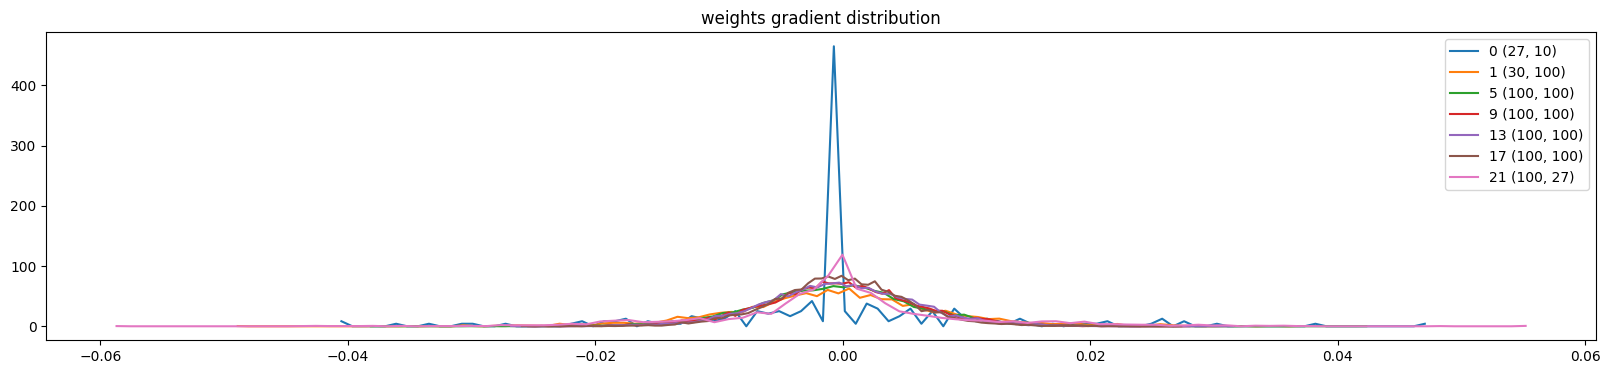

In [11]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');



layer 2 (      Tanh): mean +0.01, std 0.63, saturated: 4.56%
layer 5 (      Tanh): mean +0.00, std 0.66, saturated: 4.66%
layer 8 (      Tanh): mean -0.01, std 0.66, saturated: 4.38%
layer 11 (      Tanh): mean -0.01, std 0.67, saturated: 3.75%
layer 14 (      Tanh): mean +0.00, std 0.68, saturated: 2.88%


Text(0.5, 1.0, 'activation distribution')

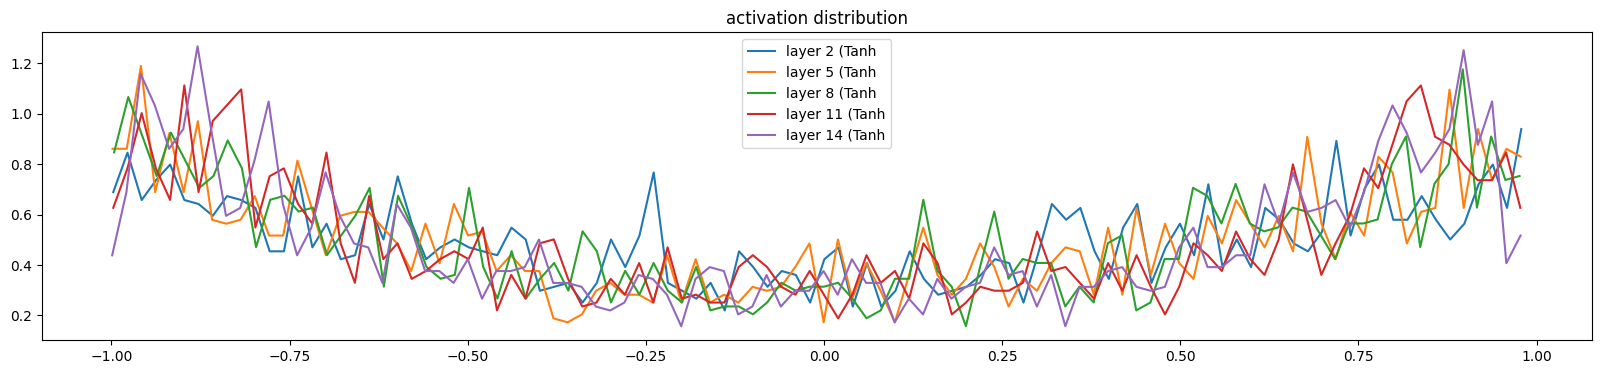

In [12]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')



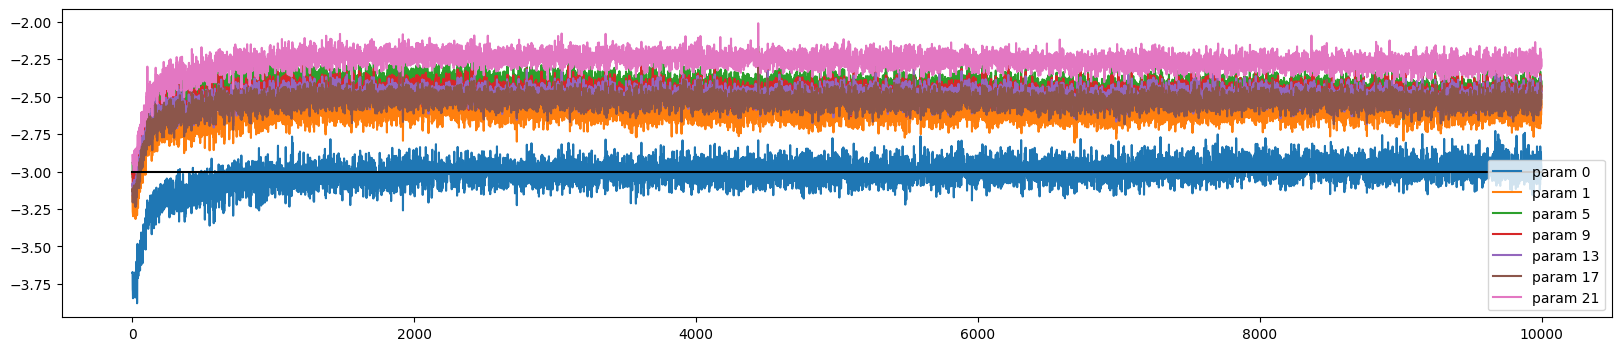

In [13]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

## Validation and sampling
Evaluation uses fixed running statistics. Sampling is defined but not invoked in the supplied cell.

In [14]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  x = forward (x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.2346510887145996
val 2.249162435531616


In [15]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

@torch.inference_mode()
def sample_names():
  for _ in range(20):

      out = []
      context = [0] * block_size # initialize with all ...
      while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        x = emb.view(emb.shape[0], -1) # concatenate the vectors
        for layer in layers:
          x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
          break

      print(''.join(itos[i] for i in out)) # decode and print the generated word

## Batching correctness
One-context sanity check followed by 128-context checks. These establish numerical consistency on tested inputs, not prediction accuracy.

In [16]:
# Use fixed running statistics in every BatchNorm layer.
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

def forward(x):
    embeddings = C[x]
    out = embeddings.reshape(x.shape[0], -1)

    for layer in layers:
        out = layer(out)

    return out

with torch.inference_mode():
    # Predict the first validation context by itself.
    alone = forward(Xdev[:1]).clone()

    # Predict 32 contexts together, then take the first result.
    in_batch = forward(Xdev[:32])[0:1].clone()

difference = (alone - in_batch).abs().max().item()

print("Largest difference between output scores:", difference)

torch.testing.assert_close(
    alone,
    in_batch,
    rtol=1e-4,
    atol=1e-5,
)

print("Passed: the first context has matching predictions.")

Largest difference between output scores: 2.980232238769531e-07
Passed: the first context has matching predictions.


In [17]:
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

batch_sizes = [1, 8, 32, 128]
Xcheck = Xdev[:128]

with torch.inference_mode():
    reference_parts = []

    for i in range(len(Xcheck)):
        one_context = Xcheck[i:i + 1]
        one_output = forward(one_context)
        reference_parts.append(one_output.clone())

    reference = torch.cat(reference_parts, dim=0)

    for b in batch_sizes:
        output_parts = []

        for start in range(0, len(Xcheck), b):
            batch = Xcheck[start:start + b]
            batch_output = forward(batch)
            output_parts.append(batch_output.clone())

        output = torch.cat(output_parts, dim=0)

        max_difference = (output - reference).abs().max().item()

        print(f"Batch {b}: maximum difference = {max_difference:.8f}")

        torch.testing.assert_close(
            output,
            reference,
            rtol=1e-4,
            atol=1e-5,
        )

        print(f"Batch {b}: passed")

Batch 1: maximum difference = 0.00000000
Batch 1: passed
Batch 8: maximum difference = 0.00000143
Batch 8: passed
Batch 32: maximum difference = 0.00000143
Batch 32: passed
Batch 128: maximum difference = 0.00000095
Batch 128: passed


## Batching performance
All timings process the same first 128 validation contexts on CPU with one PyTorch computation thread. Work includes forward calls, slicing, looping and inference-mode entry. It excludes printing, correctness comparisons, softmax and sampling.

In [18]:
from torch.utils.benchmark import Timer

assert all(p.device.type == "cpu" for p in parameters)
assert Xcheck.device.type == "cpu"

@torch.inference_mode()
def run_workload(batch_size):
    for start in range(0, len(Xcheck), batch_size):
        batch = Xcheck[start:start + batch_size]
        forward(batch)

timings = {}

for b in batch_sizes:
    timer = Timer(
        stmt="run_workload(b)",
        globals={
            "run_workload": run_workload,
            "b": b,
        },
        num_threads=1,
    )

    measurement = timer.blocked_autorange(min_run_time=1.0)
    timings[b] = measurement.median

    print(
        f"Batch {b:3d}: "
        f"{timings[b] * 1000:.3f} ms per 128 contexts"
    )

Batch   1: 26.366 ms per 128 contexts
Batch   8: 3.743 ms per 128 contexts
Batch  32: 1.390 ms per 128 contexts
Batch 128: 0.705 ms per 128 contexts


In [19]:
baseline = timings[1]

for b in batch_sizes:
    seconds = timings[b]
    throughput = len(Xcheck) / seconds
    speedup = baseline / seconds

    print(
        f"Batch {b:3d} | "
        f"{throughput:,.0f} contexts/second | "
        f"{speedup:.2f}x speedup"
    )

Batch   1 | 4,855 contexts/second | 1.00x speedup
Batch   8 | 34,197 contexts/second | 7.04x speedup
Batch  32 | 92,096 contexts/second | 18.97x speedup
Batch 128 | 181,456 contexts/second | 37.38x speedup


## Measurement variability
Repeated measurement order and IQR summaries expose environmental variability. No noisy observations are removed.

In [20]:
orders = [
    [1, 8, 32, 128],
    [128, 32, 8, 1],
    [32, 1, 128, 8],
]

repeat_times = {b: [] for b in batch_sizes}

for round_id, order in enumerate(orders, start=1):
    print(f"\nRound {round_id}: {order}")

    for b in order:
        timer = Timer(
            stmt="run_workload(b)",
            globals={
                "run_workload": run_workload,
                "b": b,
            },
            num_threads=1,
        )

        measurement = timer.blocked_autorange(min_run_time=1.0)
        seconds = measurement.median
        repeat_times[b].append(seconds)

        print(f"Batch {b:3d}: {seconds * 1000:.3f} ms")


Round 1: [1, 8, 32, 128]
Batch   1: 25.985 ms
Batch   8: 3.863 ms
Batch  32: 2.296 ms
Batch 128: 1.082 ms

Round 2: [128, 32, 8, 1]
Batch 128: 1.277 ms
Batch  32: 1.389 ms
Batch   8: 3.641 ms
Batch   1: 26.299 ms

Round 3: [32, 1, 128, 8]
Batch  32: 1.371 ms
Batch   1: 27.909 ms
Batch 128: 0.768 ms
Batch   8: 3.616 ms


In [21]:
for b in [1, 128]:
    timer = Timer(
        stmt="run_workload(b)",
        globals={
            "run_workload": run_workload,
            "b": b,
        },
        num_threads=1,
    )

    measurement = timer.blocked_autorange(min_run_time=3.0)

    print(f"\nBatch size {b}")
    print(measurement)


Batch size 1
run_workload(b)
  Median: 26.66 ms
  IQR:    3.49 ms (25.10 to 28.59)
  109 measurements, 1 runs per measurement, 1 thread
           This could indicate system fluctuation.

Batch size 128
run_workload(b)
  Median: 1.09 ms
  IQR:    0.17 ms (1.03 to 1.20)
  254 measurements, 10 runs per measurement, 1 thread
           This could indicate system fluctuation.


## Recorded environment
Two logical CPUs were visible and the default PyTorch thread count was one. CPU model, runtime package versions, quotas and exact dtype were not explicitly logged. Do not infer them from another machine.

In [22]:
import os

print("Visible logical CPUs:", os.cpu_count())
print("Default PyTorch CPU threads:", torch.get_num_threads())

Visible logical CPUs: 2
Default PyTorch CPU threads: 1


## Fold Linear and BatchNorm
For evaluation: s = gamma / sqrt(running_var + epsilon), W_new = W * s, b_new = (b - running_mean) * s + beta. Weight layout is [input, output], so broadcast scale over columns. Six pairs become six linear calls; five Tanh layers remain. Folding creates new weights; rebuild them after retraining. Embeddings are shared and must also stay fixed.

In [23]:
class FoldedLinear:
    def __init__(self, weight, bias):
        self.weight = weight
        self.bias = bias

    def __call__(self, x):
        self.out = x @ self.weight
        self.out += self.bias
        return self.out


for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False


folded_layers = []

with torch.no_grad():
    i = 0

    while i < len(layers):
        layer = layers[i]

        if isinstance(layer, Linear):
            bn = layers[i + 1]
            assert isinstance(bn, BatchNorm1d)

            mean = bn.running_mean.reshape(-1)
            variance = bn.running_var.reshape(-1)

            scale = bn.gamma / torch.sqrt(variance + bn.epsilon)

            if layer.bias is None:
                bias = torch.zeros_like(mean)
            else:
                bias = layer.bias

            folded_weight = layer.weight * scale
            folded_bias = (bias - mean) * scale + bn.beta

            folded_layers.append(
                FoldedLinear(folded_weight, folded_bias)
            )

            i += 2

        elif isinstance(layer, Tanh):
            folded_layers.append(Tanh())
            i += 1

        else:
            raise TypeError(f"Unexpected layer: {type(layer)}")


def forward_folded(x):
    embeddings = C[x]
    out = embeddings.reshape(x.shape[0], -1)

    for layer in folded_layers:
        out = layer(out)

    return out


print("Original layer count:", len(layers))
print("Folded layer count:", len(folded_layers))

Original layer count: 17
Folded layer count: 11


## Folded-model correctness on 128 contexts
Compare identical inputs at batch sizes 1, 8, 32 and 128 using rtol=1e-4 and atol=1e-5.

In [24]:
with torch.inference_mode():
    for b in [1, 8, 32, 128]:
        largest_difference = 0.0

        for start in range(0, len(Xcheck), b):
            batch = Xcheck[start:start + b]

            original = forward(batch)
            folded = forward_folded(batch)

            difference = (original - folded).abs().max().item()
            largest_difference = max(largest_difference, difference)

            torch.testing.assert_close(
                folded,
                original,
                rtol=1e-4,
                atol=1e-5,
            )

        print(
            f"Batch {b:3d}: passed | "
            f"maximum difference = {largest_difference:.8f}"
        )


Batch   1: passed | maximum difference = 0.00000203
Batch   8: passed | maximum difference = 0.00000191
Batch  32: passed | maximum difference = 0.00000191
Batch 128: passed | maximum difference = 0.00000191


## Paired performance comparison
Two model orders, four batch sizes, one CPU thread, two-second minimum timing budget per configuration. Construction of folded weights is excluded. IQR/median is a variability indicator, not a confidence interval. At batch 32, both rounds show approximately 1.87x speedup; batch 128 is inconclusive.

In [25]:
from torch.utils.benchmark import Timer

@torch.inference_mode()
def run_comparison(forward_fn, batch_size):
    for start in range(0, len(Xcheck), batch_size):
        batch = Xcheck[start:start + batch_size]
        forward_fn(batch)


models = {
    "original": forward,
    "folded": forward_folded,
}

orders = [
    ["original", "folded"],
    ["folded", "original"],
]

folding_results = {}

for round_id, order in enumerate(orders, start=1):
    print(f"\nRound {round_id}: {order}")

    for b in [1, 8, 32, 128]:
        for name in order:
            timer = Timer(
                stmt="run_comparison(fn, b)",
                globals={
                    "run_comparison": run_comparison,
                    "fn": models[name],
                    "b": b,
                },
                num_threads=1,
            )

            measurement = timer.blocked_autorange(min_run_time=2.0)
            folding_results[(round_id, b, name)] = measurement

        original_result = folding_results[(round_id, b, "original")]
        folded_result = folding_results[(round_id, b, "folded")]

        speedup = original_result.median / folded_result.median

        original_spread = 100 * original_result.iqr / original_result.median
        folded_spread = 100 * folded_result.iqr / folded_result.median

        print(
            f"Batch {b:3d} | "
            f"original: {original_result.median * 1000:.3f} ms | "
            f"folded: {folded_result.median * 1000:.3f} ms | "
            f"speedup: {speedup:.2f}x | "
            f"IQR/median: {original_spread:.1f}% / {folded_spread:.1f}%"
        )


Round 1: ['original', 'folded']
Batch   1 | original: 78.866 ms | folded: 48.037 ms | speedup: 1.64x | IQR/median: 104.9% / 72.1%
Batch   8 | original: 11.664 ms | folded: 2.712 ms | speedup: 4.30x | IQR/median: 100.4% / 12.3%
Batch  32 | original: 1.317 ms | folded: 0.703 ms | speedup: 1.87x | IQR/median: 4.6% / 2.4%
Batch 128 | original: 0.725 ms | folded: 0.556 ms | speedup: 1.30x | IQR/median: 2.4% / 44.0%

Round 2: ['folded', 'original']
Batch   1 | original: 23.470 ms | folded: 12.659 ms | speedup: 1.85x | IQR/median: 2.1% / 11.7%
Batch   8 | original: 3.528 ms | folded: 1.456 ms | speedup: 2.42x | IQR/median: 2.6% / 1.5%
Batch  32 | original: 1.311 ms | folded: 0.702 ms | speedup: 1.87x | IQR/median: 2.9% / 2.4%
Batch 128 | original: 0.735 ms | folded: 0.738 ms | speedup: 1.00x | IQR/median: 37.1% / 5.9%


## Full validation preservation
Checks all 22,767 validation contexts in batches of 128. Sum losses then divide by total examples, handling the final partial batch correctly. Zero changed argmax predictions means both implementations chose the same top character; it does not mean all characters were predicted correctly.

In [26]:
with torch.inference_mode():
    original_loss_sum = 0.0
    folded_loss_sum = 0.0
    max_difference = 0.0
    prediction_changes = 0

    for start in range(0, len(Xdev), 128):
        x = Xdev[start:start + 128]
        y = Ydev[start:start + 128]

        original = forward(x)
        folded = forward_folded(x)

        torch.testing.assert_close(
            folded,
            original,
            rtol=1e-4,
            atol=1e-5,
        )

        difference = (original - folded).abs().max().item()
        max_difference = max(max_difference, difference)

        original_loss_sum += F.cross_entropy(
            original, y, reduction="sum"
        ).item()

        folded_loss_sum += F.cross_entropy(
            folded, y, reduction="sum"
        ).item()

        prediction_changes += (
            original.argmax(dim=1) != folded.argmax(dim=1)
        ).sum().item()

    print("Validation contexts:", len(Xdev))
    print("Original loss:", original_loss_sum / len(Xdev))
    print("Folded loss:", folded_loss_sum / len(Xdev))
    print("Maximum logit difference:", max_difference)
    print("Changed top-scoring predictions:", prediction_changes)

Validation contexts: 22767
Original loss: 2.2491625373100748
Folded loss: 2.2491625567463154
Maximum logit difference: 2.86102294921875e-06
Changed top-scoring predictions: 0


## Interpretation and attribution
This study demonstrates a known inference transformation and controlled performance evaluation. The model follows the educational style of Andrej Karpathy’s makemore; confirm the precise upstream source before publishing. ChatGPT assisted with experiment design, folding code, interpretation, and documentation. Measurements were run by the author in Colab and preserved as supplied. No independent replay or statistical significance claim is made.